In [3]:
import pandas as pd
print(pd.__version__)

path1 = '../data/raw/train_identity.csv'
path2 = '../data/raw/train_transaction.csv'

2.3.3


In [4]:
identity = pd.read_csv(path1)
transaction = pd.read_csv(path2)

print("shape of Identity:",identity.shape)
print("Shape of Transaction:",transaction.shape)
print("----------")

'''print("Identity Info:")
identity.info()
print("Transaction Info:")
transaction.info()'''

print("Fraud Transaction Rates:")
transaction['isFraud'].value_counts()
print(transaction['isFraud'].value_counts(normalize=True) * 100)

print("Transaction null data:")
missing = transaction.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

for col in ['dist2', 'D7', 'D13', 'D14', 'D12', 'D6', 'D9', 'D8']:
    print(f"\n{col}")
    print(
        transaction.groupby(transaction[col].isna())['isFraud']
        .mean() * 100
    )

shape of Identity: (144233, 41)
Shape of Transaction: (590540, 394)
----------
Fraud Transaction Rates:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64
Transaction null data:
dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V139     508595
V162     508595
V161     508595
V154     508595
V138     508595
V158     508595
V157     508595
V163     508595
V156     508595
V155     508595
V149     508595
dtype: int64

dist2
dist2
False    9.915752
True     3.062326
Name: isFraud, dtype: float64

D7
D7
False    14.877817
True      2.696226
Name: isFraud, dtype: float64

D13
D13
False    11.035963
True      2.615648
Name: isFraud, dtype: float64

D14
D14
False    11.598887
True      2.545647
Name: isFraud, dtype: float64

D12
D12
False    11.740346
True      2.484676
Name: isFraud, dtype: float64

D6
D6
False    10.545589
True      2.502160
Name: isFraud, dtype: float64

D9
D9
Fa

In [36]:
print(transaction.groupby('isFraud')['TransactionAmt'].describe())

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


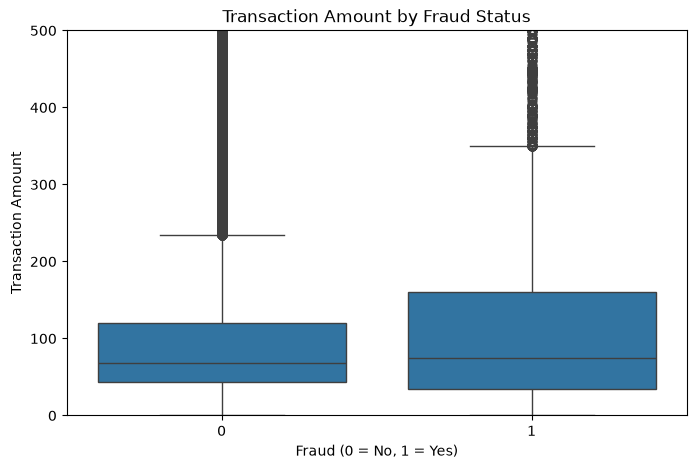

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=transaction,
    x='isFraud',
    y='TransactionAmt'
)

plt.ylim(0, 500)
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Amount')

plt.show()

In [38]:
product_fraud = (
    transaction.groupby('ProductCD')['isFraud']
    .agg(['count', 'sum', 'mean'])
)

product_fraud['fraud_rate_%'] = product_fraud['mean'] * 100

print(product_fraud.sort_values('fraud_rate_%', ascending=False))

            count   sum      mean  fraud_rate_%
ProductCD                                      
C           68519  8008  0.116873     11.687269
S           11628   686  0.058996      5.899553
H           33024  1574  0.047662      4.766231
R           37699  1426  0.037826      3.782594
W          439670  8969  0.020399      2.039939


In [39]:
for col in ['card4', 'card6']:
    print(f"\n===== {col} =====")

    result = (
        transaction.groupby(col)['isFraud']
        .agg(['count', 'sum', 'mean'])
    )

    result['fraud_rate_%'] = result['mean'] * 100

    print(result.sort_values('fraud_rate_%', ascending=False))


===== card4 =====
                   count    sum      mean  fraud_rate_%
card4                                                  
discover            6651    514  0.077282      7.728161
visa              384767  13373  0.034756      3.475610
mastercard        189217   6496  0.034331      3.433095
american express    8328    239  0.028698      2.869837

===== card6 =====
                  count    sum      mean  fraud_rate_%
card6                                                 
credit           148986   9950  0.066785      6.678480
debit            439938  10674  0.024263      2.426251
charge card          15      0  0.000000      0.000000
debit or credit      30      0  0.000000      0.000000


In [40]:
email_fraud = (
    transaction.groupby('P_emaildomain')['isFraud']
    .agg(['count', 'sum', 'mean'])
)

email_fraud['fraud_rate_%'] = email_fraud['mean'] * 100

print(
    email_fraud
    .sort_values('fraud_rate_%', ascending=False)
    .head(20)
)

                  count   sum      mean  fraud_rate_%
P_emaildomain                                        
protonmail.com       76    31  0.407895     40.789474
mail.com            559   106  0.189624     18.962433
outlook.es          438    57  0.130137     13.013699
aim.com             315    40  0.126984     12.698413
outlook.com        5096   482  0.094584      9.458399
hotmail.es          305    20  0.065574      6.557377
live.com.mx         749    41  0.054740      5.473965
hotmail.com       45250  2396  0.052950      5.295028
gmail.com        228355  9943  0.043542      4.354185
yahoo.fr            143     5  0.034965      3.496503
embarqmail.com      260     9  0.034615      3.461538
mac.com             436    14  0.032110      3.211009
icloud.com         6267   197  0.031434      3.143450
comcast.net        7888   246  0.031187      3.118661
charter.net         816    25  0.030637      3.063725
frontier.com        280     8  0.028571      2.857143
bellsouth.net      1909    5

In [41]:
email_fraud = (
    transaction.groupby('R_emaildomain')['isFraud']
    .agg(['count', 'sum', 'mean'])
)

email_fraud['fraud_rate_%'] = email_fraud['mean'] * 100

print(
    email_fraud
    .sort_values('fraud_rate_%', ascending=False)
    .head(20)
)

                count   sum      mean  fraud_rate_%
R_emaildomain                                      
protonmail.com     41    39  0.951220     95.121951
mail.com          122    46  0.377049     37.704918
netzero.net         9     2  0.222222     22.222222
outlook.com      2507   414  0.165138     16.513761
outlook.es        433    57  0.131640     13.163972
icloud.com       1398   180  0.128755     12.875536
gmail.com       57147  6811  0.119184     11.918386
hotmail.com     27509  2140  0.077793      7.779272
earthlink.net      79     6  0.075949      7.594937
hotmail.es        292    20  0.068493      6.849315
live.com.mx       754    44  0.058355      5.835544
yahoo.com       11842   610  0.051512      5.151157
live.com          762    38  0.049869      4.986877
rocketmail.com     69     3  0.043478      4.347826
suddenlink.net     25     1  0.040000      4.000000
charter.net       127     5  0.039370      3.937008
ymail.com         207     8  0.038647      3.864734
yahoo.fr    

In [42]:
transaction['email_match'] = (
    transaction['P_emaildomain'] == transaction['R_emaildomain']
)

print(
    transaction.groupby('email_match')['isFraud']
    .agg(['count', 'sum', 'mean'])
)

              count    sum      mean
email_match                         
False        488036  10771  0.022070
True         102504   9892  0.096504


In [43]:
result = (
    transaction.groupby('email_match')['isFraud']
    .agg(['count', 'sum', 'mean'])
)

result['fraud_rate_%'] = result['mean'] * 100

print(result)

              count    sum      mean  fraud_rate_%
email_match                                       
False        488036  10771  0.022070      2.207009
True         102504   9892  0.096504      9.650355


In [44]:
c_cols = [col for col in transaction.columns if col.startswith('C')]

c_fraud = transaction[c_cols + ['isFraud']].corr()['isFraud'].sort_values(
    ascending=False
)

print(c_fraud)

isFraud    1.000000
C2         0.037229
C8         0.032139
C12        0.031905
C1         0.030570
C4         0.030382
C10        0.028396
C7         0.028160
C11        0.027484
C6         0.020909
C14        0.007921
C3        -0.006833
C13       -0.011146
C5        -0.030754
C9        -0.031703
Name: isFraud, dtype: float64


In [45]:
transaction['C2_bin'] = pd.qcut(
    transaction['C2'],
    q=10,
    duplicates='drop'
)

c2_analysis = (
    transaction.groupby('C2_bin', observed=True)['isFraud']
    .agg(['count', 'sum', 'mean'])
)

c2_analysis['fraud_rate_%'] = c2_analysis['mean'] * 100

print(c2_analysis)

                count   sum      mean  fraud_rate_%
C2_bin                                             
(-0.001, 1.0]  316704  7320  0.023113      2.311306
(1.0, 2.0]     103948  3324  0.031978      3.197753
(2.0, 4.0]      80021  3295  0.041177      4.117669
(4.0, 7.0]      35035  1823  0.052034      5.203368
(7.0, 5691.0]   54832  4901  0.089382      8.938211


In [46]:
d_cols = [col for col in transaction.columns if col.startswith('D')]

d_fraud = transaction[d_cols + ['isFraud']].corr()['isFraud'].sort_values(
    ascending=False
)

print(d_fraud)

isFraud    1.000000
D14       -0.008663
D12       -0.028864
D9        -0.044253
D11       -0.045094
D3        -0.046271
D6        -0.057236
D13       -0.059430
D5        -0.064638
D1        -0.067193
D4        -0.067216
D10       -0.072002
D15       -0.077519
D2        -0.083583
D7        -0.127199
D8        -0.142636
Name: isFraud, dtype: float64


In [47]:
transaction['D8_bin'] = pd.qcut(
    transaction['D8'],
    q=5,
    duplicates='drop'
)

d8_analysis = (
    transaction.groupby('D8_bin', observed=True)['isFraud']
    .agg(['count', 'sum', 'mean'])
)

d8_analysis['fraud_rate_%'] = d8_analysis['mean'] * 100

print(d8_analysis)

                     count   sum      mean  fraud_rate_%
D8_bin                                                  
(-0.001, 0.875]      16284  2803  0.172132     17.213215
(0.875, 15.542]      13710  2495  0.181984     18.198395
(15.542, 82.0]       14964  1306  0.087276      8.727613
(82.0, 241.625]      14990   788  0.052568      5.256838
(241.625, 1707.792]  14978   435  0.029043      2.904260


In [48]:
m_cols = [col for col in transaction.columns if col.startswith('M')]

for col in m_cols:
    print(f"\n===== {col} =====")

    result = (
        transaction.groupby(col)['isFraud']
        .agg(['count', 'sum', 'mean'])
    )

    result['fraud_rate_%'] = result['mean'] * 100

    print(result.sort_values('fraud_rate_%', ascending=False))


===== M1 =====
     count   sum      mean  fraud_rate_%
M1                                      
T   319415  6342  0.019855      1.985505
F       25     0  0.000000      0.000000

===== M2 =====
     count   sum      mean  fraud_rate_%
M2                                      
F    33972  1184  0.034852      3.485223
T   285468  5158  0.018069      1.806858

===== M3 =====
     count   sum      mean  fraud_rate_%
M3                                      
F    67709  2049  0.030262      3.026186
T   251731  4293  0.017054      1.705392

===== M4 =====
     count   sum      mean  fraud_rate_%
M4                                      
M2   59865  6809  0.113739     11.373925
M0  196405  7198  0.036649      3.664876
M1   52826  1429  0.027051      2.705107

===== M5 =====
     count   sum      mean  fraud_rate_%
M5                                      
T   107567  4055  0.037697      3.769744
F   132491  3514  0.026523      2.652256

===== M6 =====
     count   sum      mean  fraud_rate_%
M6

In [49]:
v_cols = [col for col in transaction.columns if col.startswith('V')]

v_corr = (
    transaction[v_cols + ['isFraud']]
    .corr(numeric_only=True)['isFraud']
    .drop('isFraud')
    .sort_values(key=abs, ascending=False)
)

print(v_corr.head(20))

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


In [50]:
transaction['V257_bin'] = pd.qcut(
    transaction['V257'],
    q=5,
    duplicates='drop'
)

v257_analysis = (
    transaction.groupby('V257_bin', observed=True)['isFraud']
    .agg(['count', 'sum', 'mean'])
)

v257_analysis['fraud_rate_%'] = v257_analysis['mean'] * 100

print(v257_analysis)

                count   sum      mean  fraud_rate_%
V257_bin                                           
(-0.001, 1.0]  115843  4956  0.042782      4.278204
(1.0, 48.0]     14587  5236  0.358950     35.894975


In [51]:
v257_missing = (
    transaction.groupby(transaction['V257'].isna())['isFraud']
    .agg(['count', 'sum', 'mean'])
)

v257_missing['fraud_rate_%'] = v257_missing['mean'] * 100

print(v257_missing)

        count    sum      mean  fraud_rate_%
V257                                        
False  130430  10192  0.078142      7.814153
True   460110  10471  0.022758      2.275760


In [52]:
transaction.drop(
    columns=['email_match', 'C2_bin', 'D8_bin', 'V257_bin'],
    inplace=True,
    errors='ignore'
)

In [53]:
print(transaction.shape)

(590540, 394)


In [5]:
v_cols = [col for col in transaction.columns if col.startswith('V')]

v_corr_matrix = transaction[v_cols].corr()

# Get the strongest correlations between different V features
corr_pairs = (
    v_corr_matrix
    .where(~__import__('numpy').eye(len(v_corr_matrix), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(20))


V322  V95     0.999949
V95   V322    0.999949
V96   V323    0.999948
V323  V96     0.999948
V97   V324    0.999947
V324  V97     0.999947
V101  V322    0.999698
V322  V101    0.999698
V279  V322    0.999624
V322  V279    0.999624
V101  V95     0.999594
V95   V101    0.999594
V293  V279    0.999568
V279  V293    0.999568
V280  V324    0.999464
V324  V280    0.999464
V293  V322    0.999403
V322  V293    0.999403
V167  V177    0.999364
V177  V167    0.999364
dtype: float64


In [55]:
top_v = v_corr.head(20).index

print(
    transaction[top_v]
    .corr()
    .round(3)
)

       V257   V246   V244   V242   V201   V200   V189   V188   V258    V45  \
V257  1.000  0.906  0.758  0.754  0.733  0.748  0.516  0.520  0.779  0.742   
V246  0.906  1.000  0.829  0.827  0.675  0.680  0.573  0.574  0.740  0.669   
V244  0.758  0.829  1.000  0.974  0.537  0.531  0.665  0.656  0.711  0.450   
V242  0.754  0.827  0.974  1.000  0.533  0.526  0.645  0.633  0.710  0.456   
V201  0.733  0.675  0.537  0.533  1.000  0.942  0.802  0.740  0.637  0.670   
V200  0.748  0.680  0.531  0.526  0.942  1.000  0.714  0.784  0.627  0.661   
V189  0.516  0.573  0.665  0.645  0.802  0.714  1.000  0.899  0.462  0.381   
V188  0.520  0.574  0.656  0.633  0.740  0.784  0.899  1.000  0.442  0.372   
V258  0.779  0.740  0.711  0.710  0.637  0.627  0.462  0.442  1.000  0.665   
V45   0.742  0.669  0.450  0.456  0.670  0.661  0.381  0.372  0.665  1.000   
V158  0.441  0.391  0.342  0.353  0.491  0.528  0.390  0.395  0.155  0.371   
V156  0.353  0.399  0.370  0.368  0.417  0.414  0.419  0.420  0.

In [10]:
cols = [i for i in transaction.columns if i.startswith("C")]
cor = transaction[cols].corr()
print(cor)






           C1        C2        C3        C4        C5        C6        C7  \
C1   1.000000  0.995089 -0.003467  0.967800  0.165862  0.982238  0.926258   
C2   0.995089  1.000000 -0.003339  0.972134  0.126540  0.974845  0.938867   
C3  -0.003467 -0.003339  1.000000 -0.001720 -0.008101 -0.004711 -0.001730   
C4   0.967800  0.972134 -0.001720  1.000000 -0.012842  0.962319  0.895092   
C5   0.165862  0.126540 -0.008101 -0.012842  1.000000  0.232409 -0.009970   
C6   0.982238  0.974845 -0.004711  0.962319  0.232409  1.000000  0.858583   
C7   0.926258  0.938867 -0.001730  0.895092 -0.009970  0.858583  1.000000   
C8   0.967746  0.975863 -0.001203  0.959995 -0.011654  0.921972  0.982983   
C9   0.175999  0.133566 -0.010074 -0.015970  0.925786  0.250695 -0.012399   
C10  0.958202  0.970624 -0.001494  0.952466 -0.011846  0.914440  0.985062   
C11  0.996515  0.993898 -0.003583  0.974547  0.168862  0.991105  0.915209   
C12  0.927939  0.940258 -0.001763  0.894619 -0.009875  0.858182  0.999489   

In [6]:
vcols = [i for i in transaction.columns if i.startswith("V")]
cor = transaction[vcols].corr()
print(cor)

            V1        V2        V3        V4        V5        V6        V7  \
V1    1.000000  0.032168  0.024830  0.014216  0.013619  0.032284  0.026016   
V2    0.032168  1.000000  0.773039  0.318554  0.305504  0.621459  0.496921   
V3    0.024830  0.773039  1.000000  0.243684  0.353767  0.472570  0.546875   
V4    0.014216  0.318554  0.243684  1.000000  0.915164  0.279596  0.221621   
V5    0.013619  0.305504  0.353767  0.915164  1.000000  0.261490  0.294447   
...        ...       ...       ...       ...       ...       ...       ...   
V335       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V336       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V337       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V338       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V339       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

            V8        V9       V10  ...      V330      V331    

In [10]:
vcols = [i for i in transaction.columns if i.startswith("V")]

cor = transaction[vcols].corr()

threshold = 0.95

high_corr_pairs = []

for i in range(len(cor.columns)):
    for j in range(i + 1, len(cor.columns)):
        corr_value = cor.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs.append(
                [cor.columns[i], cor.columns[j]]
            )

for pair in high_corr_pairs:
    print(pair)

['V10', 'V11']
['V15', 'V16']
['V15', 'V33']
['V15', 'V57']
['V15', 'V94']
['V17', 'V18']
['V17', 'V21']
['V21', 'V22']
['V21', 'V84']
['V27', 'V28']
['V28', 'V89']
['V29', 'V30']
['V31', 'V32']
['V31', 'V50']
['V31', 'V71']
['V31', 'V92']
['V32', 'V50']
['V33', 'V34']
['V33', 'V94']
['V42', 'V43']
['V42', 'V63']
['V42', 'V84']
['V48', 'V49']
['V50', 'V71']
['V50', 'V92']
['V51', 'V52']
['V51', 'V94']
['V57', 'V58']
['V59', 'V60']
['V63', 'V84']
['V69', 'V70']
['V71', 'V72']
['V71', 'V92']
['V73', 'V74']
['V80', 'V81']
['V90', 'V91']
['V92', 'V93']
['V95', 'V101']
['V95', 'V126']
['V95', 'V132']
['V95', 'V143']
['V95', 'V164']
['V95', 'V167']
['V95', 'V177']
['V95', 'V202']
['V95', 'V211']
['V95', 'V279']
['V95', 'V293']
['V95', 'V306']
['V95', 'V316']
['V95', 'V322']
['V95', 'V331']
['V96', 'V97']
['V96', 'V102']
['V96', 'V103']
['V96', 'V127']
['V96', 'V128']
['V96', 'V133']
['V96', 'V134']
['V96', 'V168']
['V96', 'V178']
['V96', 'V179']
['V96', 'V212']
['V96', 'V213']
['V96', 'V280'

In [8]:
to_drop = set()

for col1, col2, corr_value in high_corr_pairs:
    to_drop.add(col2)

print("Number of columns to drop:", len(to_drop))
print(to_drop)

Number of columns to drop: 124
{'V57', 'V318', 'V332', 'V231', 'V16', 'V199', 'V91', 'V327', 'V275', 'V304', 'V254', 'V217', 'V18', 'V93', 'V292', 'V72', 'V196', 'V154', 'V106', 'V276', 'V202', 'V151', 'V263', 'V50', 'V168', 'V331', 'V330', 'V167', 'V92', 'V213', 'V102', 'V219', 'V60', 'V134', 'V253', 'V225', 'V155', 'V295', 'V306', 'V22', 'V178', 'V232', 'V269', 'V317', 'V143', 'V101', 'V177', 'V11', 'V132', 'V28', 'V63', 'V272', 'V279', 'V43', 'V299', 'V308', 'V49', 'V156', 'V103', 'V333', 'V212', 'V233', 'V81', 'V71', 'V296', 'V277', 'V324', 'V204', 'V329', 'V34', 'V266', 'V32', 'V128', 'V206', 'V334', 'V97', 'V160', 'V249', 'V94', 'V33', 'V244', 'V237', 'V58', 'V323', 'V84', 'V182', 'V211', 'V278', 'V280', 'V149', 'V70', 'V251', 'V293', 'V150', 'V311', 'V52', 'V326', 'V322', 'V316', 'V153', 'V273', 'V164', 'V21', 'V127', 'V30', 'V74', 'V328', 'V193', 'V145', 'V294', 'V307', 'V179', 'V158', 'V236', 'V133', 'V265', 'V192', 'V222', 'V163', 'V89', 'V256', 'V159', 'V298', 'V126'}


In [9]:
transaction[["V95", "V322", "isFraud"]].corr()["isFraud"]

V95       -0.004120
V322      -0.021541
isFraud    1.000000
Name: isFraud, dtype: float64

In [11]:
for j, k in high_corr_pairs:

    corr_target = transaction[[j, k, "isFraud"]].corr()["isFraud"]

    print(f"\nPair: {j} <-> {k}")
    print(corr_target)


Pair: V10 <-> V11
V10       -0.074658
V11       -0.071950
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V15 <-> V16
V15        0.177963
V16        0.174318
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V15 <-> V33
V15        0.177963
V33        0.183486
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V15 <-> V57
V15        0.177963
V57        0.168887
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V15 <-> V94
V15        0.177963
V94        0.188407
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V17 <-> V18
V17        0.182673
V18        0.182550
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V17 <-> V21
V17        0.182673
V21        0.165985
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V21 <-> V22
V21        0.165985
V22        0.158814
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V21 <-> V84
V21        0.165985
V84        0.169110
isFraud    1.000000
Name: isFraud, dtype: float64

Pair: V27 <-> V28


In [12]:
# Get all V columns
vcols = [col for col in transaction.columns if col.startswith("V")]

# Correlation matrix
cor = transaction[vcols].corr()

# Threshold for highly correlated features
threshold = 0.95

# Store highly correlated pairs
high_corr_pairs = []

for i in range(len(cor.columns)):
    for j in range(i + 1, len(cor.columns)):

        corr_value = cor.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs.append(
                (cor.columns[i], cor.columns[j], corr_value)
            )


# Compare each correlated pair
results = []

for feature_1, feature_2, feature_corr in high_corr_pairs:

    # Correlation with target
    fraud_corr_1 = transaction[[feature_1, "isFraud"]].corr().iloc[0, 1]
    fraud_corr_2 = transaction[[feature_2, "isFraud"]].corr().iloc[0, 1]

    # Missing percentage
    missing_1 = transaction[feature_1].isna().mean() * 100
    missing_2 = transaction[feature_2].isna().mean() * 100

    # Number of unique values
    unique_1 = transaction[feature_1].nunique()
    unique_2 = transaction[feature_2].nunique()

    results.append({
        "feature_1": feature_1,
        "feature_2": feature_2,
        "feature_corr": feature_corr,

        "feature_1_fraud_corr": fraud_corr_1,
        "feature_2_fraud_corr": fraud_corr_2,

        "feature_1_missing_%": missing_1,
        "feature_2_missing_%": missing_2,

        "feature_1_unique": unique_1,
        "feature_2_unique": unique_2
    })


# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort by highest correlation between features
results_df = results_df.sort_values(
    by="feature_corr",
    key=abs,
    ascending=False
)

print(results_df)

    feature_1 feature_2  feature_corr  feature_1_fraud_corr  \
50        V95      V322      0.999949             -0.004120   
68        V96      V323      0.999948             -0.005484   
88        V97      V324      0.999947             -0.004491   
106      V101      V322      0.999698             -0.004712   
455      V279      V322      0.999624             -0.003751   
..        ...       ...           ...                   ...   
192      V128      V212      0.950472             -0.001930   
521      V317      V322      0.950366              0.005010   
539      V329      V333      0.950356             -0.023099   
262      V148      V149      0.950232              0.228891   
70        V96      V329      0.950165             -0.005484   

     feature_2_fraud_corr  feature_1_missing_%  feature_2_missing_%  \
50              -0.021541             0.053172            86.054967   
68              -0.023329             0.053172            86.054967   
88              -0.024006     